In [1]:
import json
from pathlib import Path

In this notebook we split the available data into training and validation sets.
This cannot be done by simply taking 20% of data for test, as temporally close samples are similar.
We should care about this when making the splitting. 

In order to do this cleverly, I propose to:

    1. select two months per year ( /!\ change months per year  /!\ )
    
    2. Use a "buffer period" before and after the two months so that there is no test leak in the training set.

source of speed values (PAPER): Measurements of Solar Differential Rotation Using the Century Long Kodaikanal Sunspot Data (2021)

In [2]:
equator_speed =  14.4 # degrees per day
max_lat_speed =  13.2 # degrees per day

equator_period =  360 / equator_speed
max_lat_period =  360 / max_lat_speed

print('equator period: ', equator_period)
print('max lat period: ', max_lat_period)

half_rotation_period_eq = equator_period / 2
half_rotation_period_max_lat = max_lat_period / 2

print('half rotation period eq: ', half_rotation_period_eq)
print('half rotation period max lat: ', half_rotation_period_max_lat)

equator period:  25.0
max lat period:  27.272727272727273
half rotation period eq:  12.5
half rotation period max lat:  13.636363636363637


It is reasonable to consider a buffer period of 14 days to avoid test data leakage

(the sunspots have the time to either die or disappear on the dark side of the sun)

MAYBE REDUCE THIS AS ASPECT OF ACTIVE REGIONS CHANGE A LOT IN 14 DAYS

In [3]:
buffer_days = 10 # MAYBE REDUCE THIS AS ASPECT OF ACTIVE REGIONS CHANGE A LOT IN 14 DAYS
test_months_per_year = 2
dataset_span = [2012, 2023]

In [4]:
# print(len(triplet_json))
# print(triplet_json)
# with open(triplet_json_fname, 'w') as f:
#     json.dump(triplet_json,f, indent=4)

In [5]:
# Path to the Traslation dataset:
dataset_dir = Path('../datasets/ImageTranslationDEC2023/')
# triplet_json_fname = dataset_dir / 'wl_dr_cal_matchings.json'
# triplet_json_fname = dataset_dir / 'wl_dr_cal_matchings_new_max8h.json'
# triplet_json_fname = dataset_dir / 'wl_dr_cal_matchings_new_max8h_v2.json'
triplet_json_fname = dataset_dir / 'wl_dr_cal_matchings_new_max4h_aligned.json'

triplet_json = None

with open(triplet_json_fname, 'r') as f:
    triplet_json = json.load(f)
    

In [6]:

# In order to hafe sufficient diversity in the test set, we choose one summer month and one winter month.
test_months_per_year = {
    2012:   [7],
    2013: [2,8],
    2014: [3,9],
    2015: [2,8],
    2016: [1,7],
    2017: [2,8],

    2018: [3,9],
    2019: [2,8],
    2020: [1,7],
    2021: [2,8],
    2022: [3,9],
    2023: [2,8]
}

In [7]:
# create a dictionary of dictionnaries of all the dates in the dataset
# for each year, for each month
dates = {}
for i, t in enumerate(triplet_json):
    datetime = t['dr_datetime']
    year = datetime['year']
    month = datetime['month']
    day = datetime['day']

    if year not in dates:
        dates[year] = {}
    if month not in dates[year]:    
        dates[year][month] = []
    dates[year][month].append((day, i))

print(dates)
print()
dates2 = { k: list(dates[k].keys()) for k in dates.keys() }
print(dates2)

{'2012': {'07': [('11', 0), ('12', 1), ('18', 2), ('22', 3), ('23', 4), ('24', 5), ('25', 6), ('26', 7), ('27', 8), ('29', 9)], '08': [('01', 10), ('02', 11), ('03', 12), ('04', 13), ('05', 14), ('09', 15), ('10', 16), ('11', 17), ('12', 18), ('13', 19), ('14', 20), ('15', 21), ('16', 22), ('17', 23), ('18', 24), ('19', 25), ('20', 26), ('21', 27), ('22', 28), ('23', 29), ('24', 30), ('27', 31), ('28', 32), ('29', 33), ('30', 34)], '09': [('01', 35), ('02', 36), ('04', 37), ('06', 38), ('07', 39), ('08', 40), ('09', 41), ('10', 42), ('12', 43), ('15', 44), ('16', 45), ('17', 46), ('19', 47), ('20', 48), ('22', 49), ('25', 50), ('26', 51), ('27', 52), ('28', 53), ('29', 54), ('30', 55)], '10': [('01', 56), ('02', 57), ('04', 58), ('07', 59), ('09', 60), ('10', 61), ('11', 62), ('14', 63), ('15', 64), ('19', 65), ('21', 66), ('22', 67), ('23', 68), ('24', 69), ('27', 70), ('28', 71), ('31', 72)], '11': [('02', 73), ('06', 74), ('11', 75), ('14', 76), ('20', 77), ('22', 78), ('25', 79), (

In [8]:
num_tests = {}
test_triplets_indices = []
for y in test_months_per_year:
    print('year: ', y)
    num_tests[y] = 0
    for m in test_months_per_year[y]:
        # transform month number to string of length 2, with leading 0 if necessary
        print('month: ', m)
        num_tests[y] += len(dates[str(y)][str(m).zfill(2)])
        test_triplets_indices.extend(dates[str(y)][str(m).zfill(2)])
test_triplets_indices = [i for _, i in test_triplets_indices]

print(num_tests)
print(test_triplets_indices)
print(f"Total number of test set images: {sum(num_tests.values())}")

year:  2012
month:  7
year:  2013
month:  2
month:  8
year:  2014
month:  3
month:  9
year:  2015
month:  2
month:  8
year:  2016
month:  1
month:  7
year:  2017
month:  2
month:  8
year:  2018
month:  3
month:  9
year:  2019
month:  2
month:  8
year:  2020
month:  1
month:  7
year:  2021
month:  2
month:  8
year:  2022
month:  3
month:  9
year:  2023
month:  2
month:  8
{2012: 10, 2013: 34, 2014: 39, 2015: 44, 2016: 34, 2017: 31, 2018: 39, 2019: 42, 2020: 34, 2021: 37, 2022: 49, 2023: 38}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 551, 552, 553, 554

Now, for each test month, compute the no-go periods to avoid test leakage.

In [9]:
# compute the number of training images that we have to remove
# to avoid having training images that are too close to the test images

def get_num_train_images_to_remove(dates, y, m, buffer_days):
    num_train_images_to_remove_before_m = 0
    num_train_images_to_remove_after_m = 0

    images_to_remove = {}

    # if the previous month is in the previous year
    if m-1 == 0: 
        if str(y-1) in dates:
            # add the number of images in the previous month that are closer than the buffer
            num_train_images_to_remove_before_m += len([d for d in dates[str(y-1)][str(12)] if int(d[0]) > 31 - buffer_days])
            images_to_remove[str(y-1)] = { 12: [d for d in dates[str(y-1)][str(12)] if int(d[0]) > 31 - buffer_days] }
        else:
            num_train_images_to_remove_before_m += 0
            images_to_remove[str(y-1)] = { 12: [] }
    else:
        if str(m-1).zfill(2) not in dates[str(y)]:
            num_train_images_to_remove_before_m += 0
            images_to_remove[str(y)] = { str(m-1).zfill(2): [] }
        else:
            # add the number of images in the previous month that are closer than the buffer
            num_train_images_to_remove_before_m += len([d for d in dates[str(y)][str(m-1).zfill(2)] if int(d[0]) > 31 - buffer_days])
            images_to_remove[str(y)] = { str(m-1).zfill(2): [d for d in dates[str(y)][str(m-1).zfill(2)] if int(d[0]) > 31 - buffer_days] }

    # if the next month is in the next year
    if m+1 == 13:
        if str(y+1) in dates:
            # add the number of images in the next month that are closer than the buffer
            num_train_images_to_remove_after_m += len([d for d in dates[str(y+1)][1] if int(d[0]) <= buffer_days])
            images_to_remove[str(y+1)] = { 1: [d for d in dates[str(y+1)][1] if int(d[0]) <= buffer_days] }
        else:
            num_train_images_to_remove_after_m += 0
            images_to_remove[str(y+1)] = { 1: [] }
    else:
        if str(m+1).zfill(2) not in dates[str(y)]:
            num_train_images_to_remove_after_m += 0
            images_to_remove[str(y)]= { str(m+1).zfill(2): [] }
        else:
            # add the number of images in the next month that are closer than the buffer
            num_train_images_to_remove_after_m += len([d for d in dates[str(y)][str(m+1).zfill(2)] if int(d[0]) <= buffer_days])
            images_to_remove[str(y)] = { str(m+1).zfill(2): [d for d in dates[str(y)][str(m+1).zfill(2)] if int(d[0]) <= buffer_days] }

    return (num_train_images_to_remove_before_m, num_train_images_to_remove_after_m) , \
            images_to_remove

lost_triplets = {}
for y in test_months_per_year:
    m1 = test_months_per_year[y][0]
    m2 = test_months_per_year[y][1] if len(test_months_per_year[y]) > 1 else m1
    print('year: ', y)
    print('months: ', m1, m2)

    num_m1_remove, m1_remove = get_num_train_images_to_remove(dates, y, m1, buffer_days)
    num_m2_remove, m2_remove = get_num_train_images_to_remove(dates, y, m2, buffer_days)

    print('num m1 remove: ', num_m1_remove)
    print('m1 remove: ', m1_remove)
    print('num m2 remove: ', num_m2_remove)
    print('m2 remove: ', m2_remove)

    lost_triplets[y] = { m1-1: num_m1_remove[0],
                         m1+1: num_m1_remove[1],
                         m2-1: num_m2_remove[0], 
                         m2+1: num_m2_remove[1] }

total_lost_triplets = 0
for y in lost_triplets:
    for m in lost_triplets[y]:
        total_lost_triplets += lost_triplets[y][m]

print('total lost triplets: ', total_lost_triplets)






year:  2012
months:  7 7
num m1 remove:  (0, 7)
m1 remove:  {'2012': {'08': [('01', 10), ('02', 11), ('03', 12), ('04', 13), ('05', 14), ('09', 15), ('10', 16)]}}
num m2 remove:  (0, 7)
m2 remove:  {'2012': {'08': [('01', 10), ('02', 11), ('03', 12), ('04', 13), ('05', 14), ('09', 15), ('10', 16)]}}
year:  2013
months:  2 8
num m1 remove:  (3, 4)
m1 remove:  {'2013': {'03': [('04', 108), ('05', 109), ('06', 110), ('08', 111)]}}
num m2 remove:  (8, 9)
m2 remove:  {'2013': {'09': [('01', 173), ('02', 174), ('03', 175), ('04', 176), ('05', 177), ('06', 178), ('08', 179), ('09', 180), ('10', 181)]}}
year:  2014
months:  3 9
num m1 remove:  (0, 9)
m1 remove:  {'2014': {'04': [('01', 246), ('02', 247), ('03', 248), ('05', 249), ('06', 250), ('07', 251), ('08', 252), ('09', 253), ('10', 254)]}}
num m2 remove:  (3, 6)
m2 remove:  {'2014': {'10': [('01', 374), ('02', 375), ('03', 376), ('04', 377), ('09', 378), ('10', 379)]}}
year:  2015
months:  2 8
num m1 remove:  (3, 9)
m1 remove:  {'2015': 

In [10]:
print(f'Initially: {len(triplet_json)} triplets')
print(f'Number of test triplets: {sum(num_tests.values())}')
print(f'Number of training triplets: {len(triplet_json) - sum(num_tests.values())}')
print(f'Number of training triplets to remove: {total_lost_triplets}')
print(f'Number of training triplets after removal: {len(triplet_json) - sum(num_tests.values()) - total_lost_triplets}')

Initially: 2421 triplets
Number of test triplets: 431
Number of training triplets: 1990
Number of training triplets to remove: 259
Number of training triplets after removal: 1731


# Now in terms of Active regions

In [11]:
# Get the number of test active regions
num_test_active_regions = 0
test_triplets_data = []
for i in test_triplets_indices:
    num_test_active_regions += len(triplet_json[i]['active_regions'])
    test_triplets_data.append(triplet_json[i])

print(f'Number of test active regions: {num_test_active_regions}')

# Get the number of training active regions
num_train_active_regions = 0
train_triplets_data = []
for i in range(len(triplet_json)):
    if i not in test_triplets_indices:
        num_train_active_regions += len(triplet_json[i]['active_regions'])
        train_triplets_data.append(triplet_json[i])
print(f'Number of training active regions: {num_train_active_regions}')

ratio_train = num_train_active_regions / (num_train_active_regions + num_test_active_regions)
ratio_test = num_test_active_regions / (num_train_active_regions + num_test_active_regions)

print(f'Ratio of training active regions: {ratio_train}')
print(f'Ratio of test active regions: {ratio_test}')

Number of test active regions: 1410
Number of training active regions: 6387
Ratio of training active regions: 0.8191612158522509
Ratio of test active regions: 0.18083878414774912


In [12]:
print(test_triplets_data)

[{'dr_name': 'usd201207110845.jpg', 'wl_name': 'UPH20120711081533.FTS', 'cal_name': 'UCC20120711082941.FTS', 'dr_datetime': {'year': '2012', 'month': '07', 'day': '11', 'hours': '08', 'minutes': '45', 'seconds': '00'}, 'dr_calib': {'DateTime': '2012-07-11 08:45:00', 'NorthX': 826.0, 'NorthY': 183.0, 'CenterX': 826.0, 'CenterY': 922.0, 'Radius': 739.0, 'AngleScan': 0.0}, 'active_regions': [{'Latitude': 0.181589, 'Longitude': 2.002292}, {'Latitude': -0.247774, 'Longitude': 1.868894}, {'Latitude': -0.360601, 'Longitude': 1.685919}, {'Latitude': -0.264275, 'Longitude': 1.489305}], 'wl2cal_time_diff': -848.0, 'dr2wl_time_diff': 1767.0}, {'dr_name': 'usd201207120940.jpg', 'wl_name': 'UPH20120712092909.FTS', 'cal_name': 'UCC20120712091243.FTS', 'dr_datetime': {'year': '2012', 'month': '07', 'day': '12', 'hours': '09', 'minutes': '40', 'seconds': '00'}, 'dr_calib': {'DateTime': '2012-07-12 09:40:00', 'NorthX': 824.0, 'NorthY': 184.0, 'CenterX': 825.0, 'CenterY': 923.0, 'Radius': 739.000677, 'A

# Time Differences between CaIIK and WL

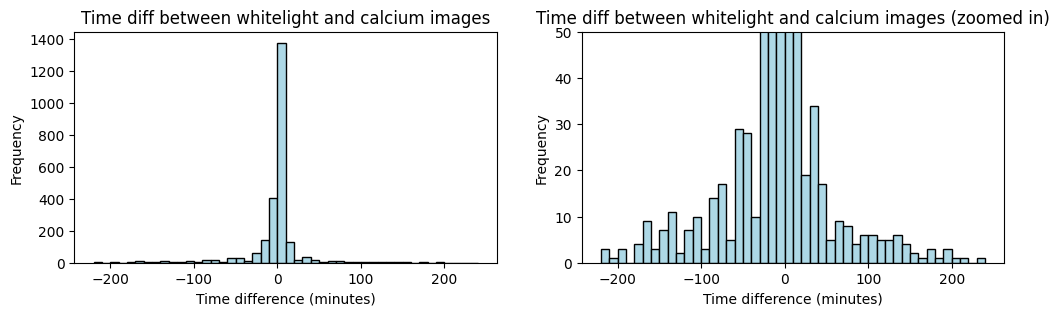

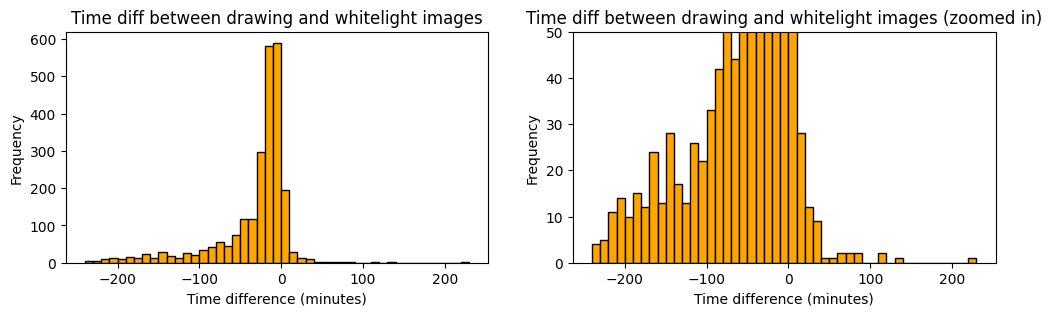

In [13]:
from datetime import datetime, timedelta
import sys
sys.path.append('..')

import utilities as ut
import matplotlib.pyplot as plt

from math import floor, ceil

def get_time_difference(time1, time2):
    # print('time1: ', time1)
    # print('time2: ', time2)

    time_format = '%H:%M:%S'
    
    # Parse the time strings into datetime objects
    time1_obj = datetime.strptime(time1, time_format)
    time2_obj = datetime.strptime(time2, time_format)
    
    # Calculate the time difference
    time_difference = time1_obj - time2_obj
    
    return time_difference

total_usable_triplets = train_triplets_data + test_triplets_data

time_diffs_wl2cal = []
time_diffs_dr2wl = []
for i, t in enumerate(total_usable_triplets):
    dr_dame = t['dr_name']
    wl_name = t['wl_name']
    cal_name = t['cal_name']

    td_wl2cal = timedelta(seconds=t['wl2cal_time_diff'])
    td_dr2wl = timedelta(seconds=t['dr2wl_time_diff'])

    time_diffs_wl2cal.append(td_wl2cal)
    time_diffs_dr2wl.append(td_dr2wl)

######## WL2CAL ########
    
# Convert timedeltas to minutes
minutes = [td.total_seconds() / 60 for td in time_diffs_wl2cal]
minutes_min, minutes_max = floor(min(minutes)), ceil(max(minutes))
# print('minutes_min: ', minutes_min, 'minutes_max: ', minutes_max)
# get the closest multiple of 10 to the maximum and minimum minutes
minutes_min = minutes_min - minutes_min % 10
minutes_max = minutes_max + 10 - minutes_max % 10
# print('minutes_min: ', minutes_min, 'minutes_max: ', minutes_max)

# get bin edges such that each bin has a width of 10 minutes
bin_edges = [i for i in range(minutes_min, minutes_max, 10)]


plt.figure(figsize=(12, 3))
# first plot the histogram
ax = plt.subplot(121)
ax.hist(minutes, bins=bin_edges, edgecolor='black', color='lightblue')
ax.set_xlabel('Time difference (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Time diff between whitelight and calcium images')

# then plot the zoomed in histogram
ax = plt.subplot(122)
ax.hist(minutes, bins=bin_edges, edgecolor='black', color='lightblue')
ax.set_ylim([0, 50])
ax.set_xlabel('Time difference (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Time diff between whitelight and calcium images (zoomed in)')

plt.show()

######## DR2WL ########

# Convert timedeltas to minutes
minutes = [td.total_seconds() / 60 for td in time_diffs_dr2wl]
minutes_min, minutes_max = floor(min(minutes)), ceil(max(minutes))
# print('minutes_min: ', minutes_min, 'minutes_max: ', minutes_max)
# get the closest multiple of 10 to the maximum and minimum minutes
minutes_min = minutes_min - minutes_min % 10
minutes_max = minutes_max + 10 - minutes_max % 10
# print('minutes_min: ', minutes_min, 'minutes_max: ', minutes_max)

# get bin edges such that each bin has a width of 10 minutes
bin_edges = [i for i in range(minutes_min, minutes_max, 10)]

plt.figure(figsize=(12, 3))
# first plot the histogram
ax = plt.subplot(121)
ax.hist(minutes, bins=bin_edges, edgecolor='black', color='orange')
ax.set_xlabel('Time difference (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Time diff between drawing and whitelight images')

# then plot the zoomed in histogram
ax = plt.subplot(122)
ax.hist(minutes, bins=bin_edges, edgecolor='black', color='orange')
ax.set_ylim([0, 50])
ax.set_xlabel('Time difference (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Time diff between drawing and whitelight images (zoomed in)')
plt.show()

    

## Create json files for training and test sets

In [14]:
# Save the train and test data
train_triplets_json_fname = dataset_dir / 'train_triplets_aligned.json'
test_triplets_json_fname = dataset_dir / 'test_triplets_aligned.json'

with open(train_triplets_json_fname, 'w') as f:
    json.dump(train_triplets_data, f, indent=4)

with open(test_triplets_json_fname, 'w') as f:
    json.dump(test_triplets_data, f, indent=4)

